# Peramalan/Forecasting dengan *Long Short Term Memory*

# **1. Pendahuluan**

\**Warning: Sebelum melakukan praktikum ini, diharapkan Anda telah mempelajari teori tentang Long Short Term Memory (LSTM) terlebih dahulu**

Teori tentang LSTM dapat dibaca pada:
https://indoml.com/2018/04/13/pengenalan-long-short-term-memory-lstm-dan-gated-recurrent-unit-gru-rnn-bagian-2/




## Tujuan Praktikum
Tujuan dari praktikum ini adalah untuk mempelajari penggunakan Recurrent Neural Network (RNN) yaitu **Long Short Term Memory (LSTM)** untuk melakukan prediksi pada data yang bersifat *time-series* (data dengan fitur waktu berturutan).

LSTM dapat mengekstraksi interaksi pada data yang bersifat *sequential* (berupa sequence/urutan).

Dataset yang akan digunakan adalah *airline-passangers.csv*

Dataset airline-passangers memiliki dua fitur yaitu bulan dan jumlah penumpang *airline* (*passanger*).
Jumlah data pada dataset ini adalah 145 data.

Pada praktikum ini akan dibuat sebuah model untuk memprediksi jumlah penumpang *airline* (*passanger*) pada bulan selanjutnya.

Task yang akan dikerjakan tergolong ke dalam kasus Regresi pada data *time-series*.

## Langkah-langkah Praktikum

Langkah-langkah praktikum secara umum :


1.   Load Data yang akan digunakan
2.   Pre-process data (normalisasi)
1.   Split data training dan data test
1.   Ubah data ke dalam bentuk time-series
2.   Training model dengan data training
1.   Test model dengan data test
2.   Lakukan prediksi dengan data baru







Berikut ini adalah tampilan isi dari airline-passangers.csv

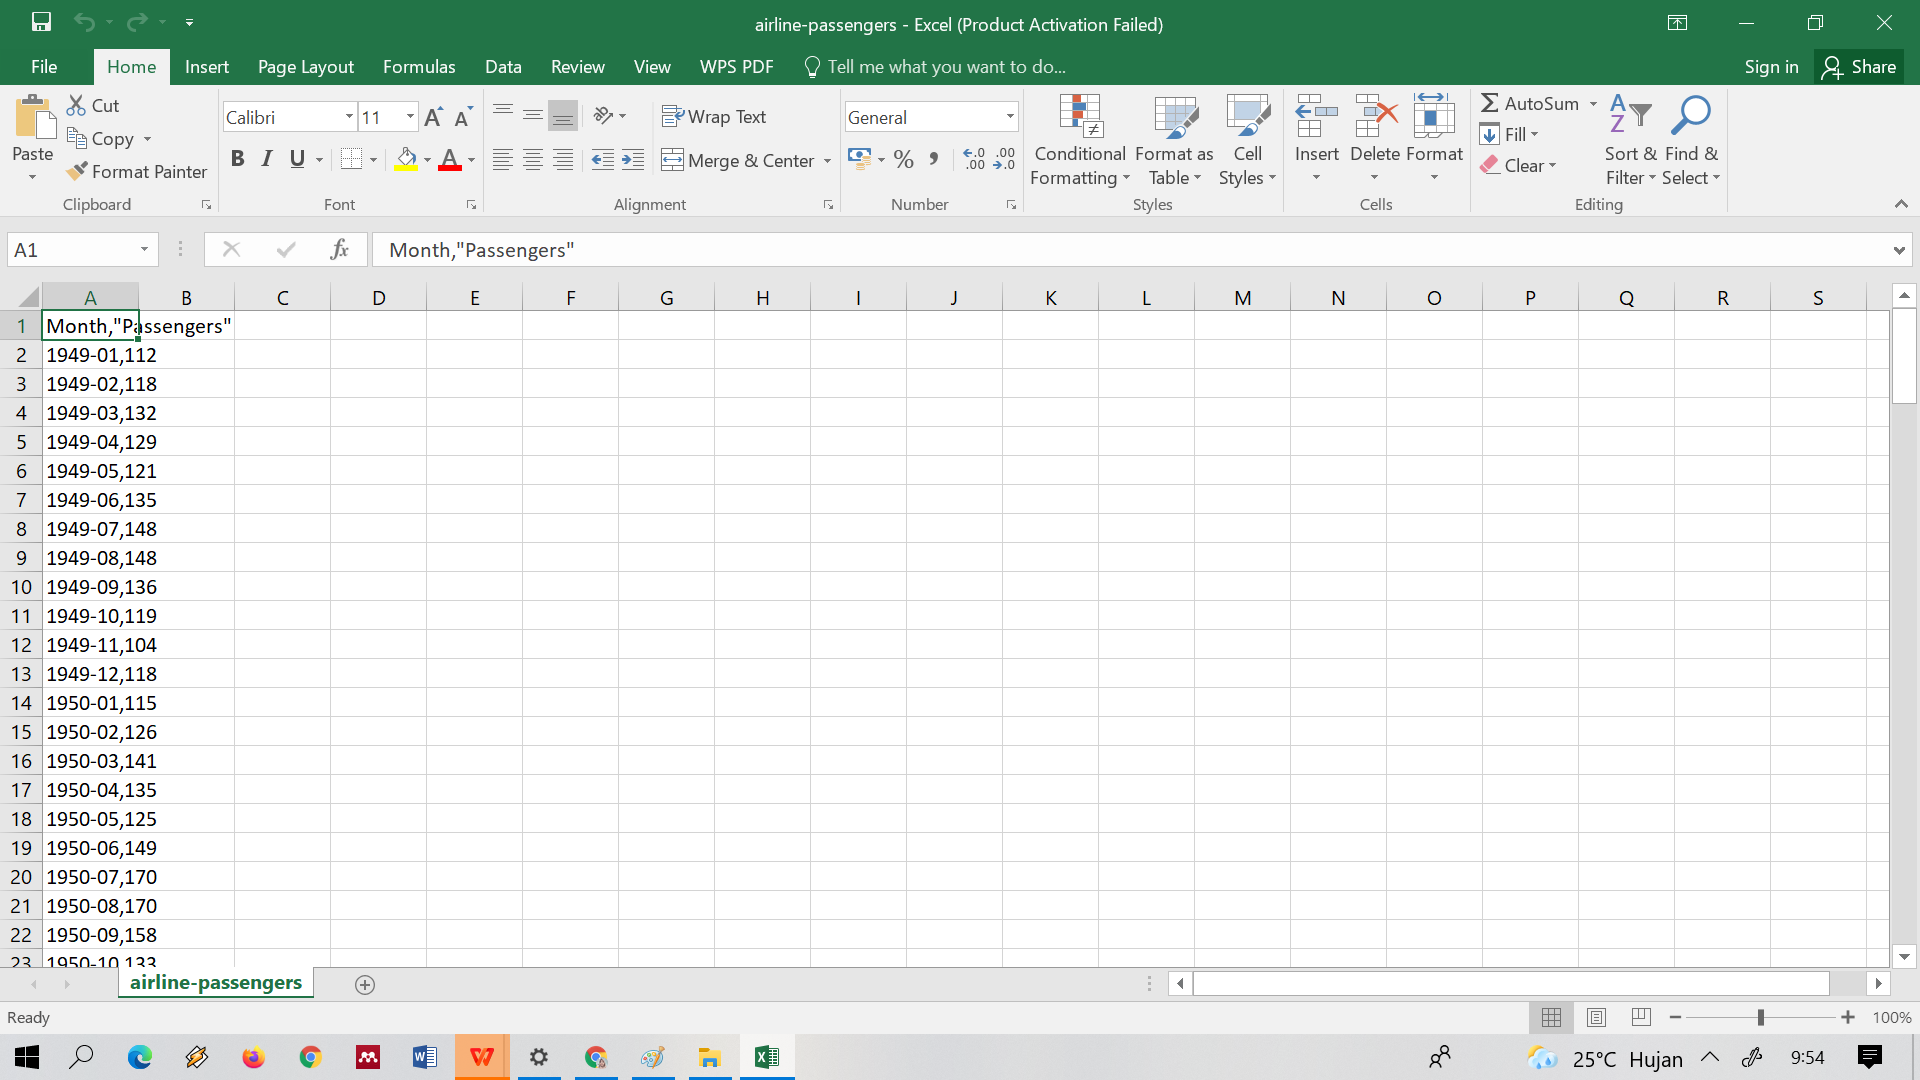

# **2. Mounting Google Drive**

In [ ]:
from google.colab import drive

# mounting dataset dari gdrive
drive.mount('/content/gdrive', force_remount=True)

# lokasi dataset - ubah sesuai dengan lokasi anda mengupload folder datanya
root_path = 'gdrive/My Drive/Deep Learning Labs/labDL07 Data/airline-passengers.csv/'

# opsional - tampilkan info lokasi dataset
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Deep Learning Labs/labDL07 Data/airline-passengers.csv/


# **3**. **Import Library yang Akan Digunakan**

In [ ]:
# import library yang akan digunakan
import numpy
import matplotlib.pyplot as plt
import pandas
import math
import os

# import library tensorflow untuk implementasi Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# **4. Baca dan Visualisasi Dataset**

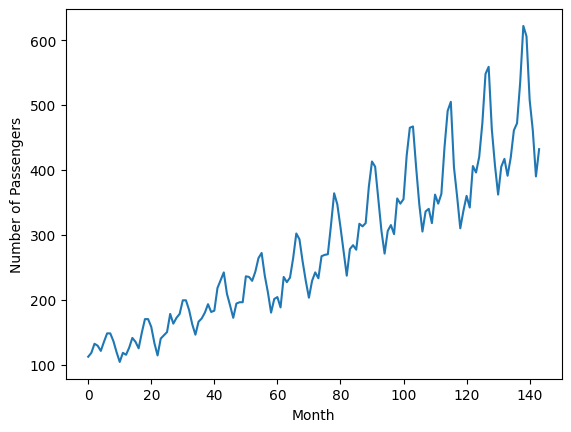

In [ ]:
# load data dan lakukan plotting untuk melihat kondisi data
import pandas
import matplotlib.pyplot as plt

root_path = 'gdrive/My Drive/Deep Learning Labs/labDL07 Data/'
datapath = os.path.join(root_path, 'airline-passengers.csv')
dataframe = pandas.read_csv(datapath, usecols=[1], engine='python')
plt.plot(dataframe)
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.show()

Dari gambar plot di atas dapat kita lihat bahwa data penumpang airline (passanger) membentuk sebuah pola. Meskipun data naik turun apabila dilihat dalam scope waktu yang kecil, namun secara keseluruhan data cenderung naik dari bulan ke 1 sampai bulan ke 144.

In [ ]:
# data diubah ke dalam format float
dataset_pre_norm = dataframe.values
dataset_pre_norm = dataset_pre_norm.astype('float32')

## **4.1. Normalisasi Data**

LSTM sangat sensitif dengan 'scale' dari data, terutama jika menggunakan fungsi aktivasi default (Sigmoid dan Tanh). Oleh karena itu kita perlu lakukan normalisasi data untuk membuat nilai data berada dalam range 0 sampai 1. Gunakan **MinMaxScaler** untuk melakukan normalisasi data.

In [ ]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset_pre_norm)

## **4.2. Split Data menjadi Data Training dan Data Test**

Selanjutnya yang akan kita lakukan adalah membagi data menjadi training set dan test set. Training set digunakan untuk membangun model, sedangkan test set digunakan untuk menguji performa model yang dibuat.

Dalam kasus ini karena data berjumlah 144, kita gunakan 120 untuk training dan sisanya untuk test.

In [ ]:
# split into train and test sets
train_size = 120
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))

120 24


Selanjutnya, data yang sudah kita miliki perlu kita ubah bentuknya untuk merepresentasikan data time-series. Dalam hal ini, kita akan menghapus fitur '***month***' pada data *airline-passangers* dan hanya akan menggunakan fitur jumlah passanger saja.

Kemudian, cara membuat data time-series adalah dengan membentuk *sequence* dari data jumlah *passanger* dalam *window* waktu yang tertentu, misalnya 1, 2, 3, atau 4.

Contoh: Jika kita pilih window = 1, maka setiap data terdiri dari dua nilai yaitu data ke-t dan data ke-t+1. Dalam hal ini nanti data ke-t+1 akan diprediksi dengan hanya menggunakan data ke-t.
Jika kita pilih window = 2, maka setiap data terdiri dari tiga nilai yaitu data ke t-1, data ke-t, dan data ke-t+1. Dalam hal ini nanti data ke-t+1 akan diprediksi dengan data ke t-1 dan data ke-t

Oleh karena itu, kita perlu membuat sebuah fungsi untuk mengkonstruksi (membangun) data time-series dari data *airline-passanger*.

# **5. Pembentukan (Konstruksi) Data Time-Series**

In [ ]:
# fungsi untuk meng-convert array ke dalam bentuk matriks time-series
# dengan window=1, karena dengan window=1 maka variabel look_back = 1,
# karena data yang akan diambil hanya data ke t dan t+1
# var look_back menyimpan jumlah window yang akan kita gunakan
def create_dataset(dataset, look_back):
    dataX, dataY=[], []
    for i in range(len(dataset) - look_back):
        # perhatikan a akan looping mulai dari data pertama
        # dan naik ke satu data berikutnya
	    a = dataset[i]
	    dataX.append(a)
	    dataY.append(dataset[i + look_back])
    return numpy.array(dataX), numpy.array(dataY)

Untuk mempermudah pemahaman, berikut ini contoh HASIL jika fungsi create_dataset diaplikasikan pada dataset yang belum dinormalisasi.

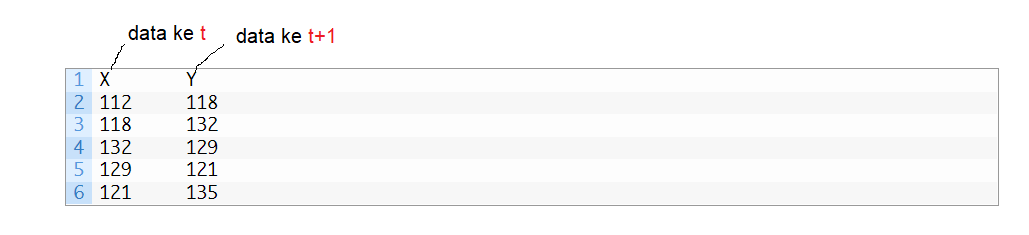

Jadi, fungsi create_dataset menghasilkan dataX yang berisi data ke-t, dan dataY yang berisi data ke-t+1

Mengapa kita perlu membentuk data seperti ini? Karena kita akan menggunakan dataX (data ke t) untuk melakukan prediksi nilai dataY (data ke t+1).

In [ ]:
# panggil fungsi create_dataset pada data yang sudah ternormalisasi
# menghasilkan data X=t and Y=t+1
look_back = 1 #ini ukuran window nya
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

In [ ]:
# tampilkan data pada trainX dan train Y
for i in range (len(trainX)):
    print(trainX[i], trainY[i])

print(len(trainX))
print(len(trainY))

[0.01544401] [0.02702703]
[0.02702703] [0.05405405]
[0.05405405] [0.04826255]
[0.04826255] [0.03281853]
[0.03281853] [0.05984557]
[0.05984557] [0.08494207]
[0.08494207] [0.08494207]
[0.08494207] [0.06177607]
[0.06177607] [0.02895753]
[0.02895753] [0.]
[0.] [0.02702703]
[0.02702703] [0.02123553]
[0.02123553] [0.04247104]
[0.04247104] [0.07142857]
[0.07142857] [0.05984557]
[0.05984557] [0.04054055]
[0.04054055] [0.08687258]
[0.08687258] [0.12741312]
[0.12741312] [0.12741312]
[0.12741312] [0.10424709]
[0.10424709] [0.05598456]
[0.05598456] [0.01930502]
[0.01930502] [0.06949806]
[0.06949806] [0.07915059]
[0.07915059] [0.08880308]
[0.08880308] [0.14285713]
[0.14285713] [0.11389962]
[0.11389962] [0.13127413]
[0.13127413] [0.14285713]
[0.14285713] [0.18339768]
[0.18339768] [0.18339768]
[0.18339768] [0.15444016]
[0.15444016] [0.11196911]
[0.11196911] [0.08108109]
[0.08108109] [0.1196911]
[0.1196911] [0.12934363]
[0.12934363] [0.14671814]
[0.14671814] [0.17181468]
[0.17181468] [0.14864865]
[0.1

Sampai di sini, apakah kalian paham mengapa jumlah data pada trainX dan trainY adalah 119 dan bukan 120?


# **6. Training Model LSTM**

Selanjutnya, yang akan kita lakukan adalah kita membangun model dengan LSTM untuk memprediksi nilai trainY dengan menggunakan nilai trainX. Setelah model berhasil dibuat, kita akan memprediksi nilai testY dengan menggunakan testX.

LSTM menerima input data dalam struktur array yang spesifik yaitu: **[samples, time steps, features]**.

Saat ini data yang kita miliki berada dalam format **[samples, features]** dan kita berasumsi bahwa satu timestep untuk setiap sample.

Oleh karena itu, kita perlu melakukan transformasi pada data trainX (yang akan dipakai untuk mentraining model) dan  testX(yang akan dipakai sebagai input saat testing) dengan numpy.reshape().

In [ ]:
# reshape input to be [samples, time steps, features]
trainX = numpy.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = numpy.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [ ]:
# Cek hasil reshape dengan print
print(trainX)

[[[0.01544401]]

 [[0.02702703]]

 [[0.05405405]]

 [[0.04826255]]

 [[0.03281853]]

 [[0.05984557]]

 [[0.08494207]]

 [[0.08494207]]

 [[0.06177607]]

 [[0.02895753]]

 [[0.        ]]

 [[0.02702703]]

 [[0.02123553]]

 [[0.04247104]]

 [[0.07142857]]

 [[0.05984557]]

 [[0.04054055]]

 [[0.08687258]]

 [[0.12741312]]

 [[0.12741312]]

 [[0.10424709]]

 [[0.05598456]]

 [[0.01930502]]

 [[0.06949806]]

 [[0.07915059]]

 [[0.08880308]]

 [[0.14285713]]

 [[0.11389962]]

 [[0.13127413]]

 [[0.14285713]]

 [[0.18339768]]

 [[0.18339768]]

 [[0.15444016]]

 [[0.11196911]]

 [[0.08108109]]

 [[0.1196911 ]]

 [[0.12934363]]

 [[0.14671814]]

 [[0.17181468]]

 [[0.14864865]]

 [[0.15250966]]

 [[0.22007722]]

 [[0.24324325]]

 [[0.26640925]]

 [[0.2027027 ]]

 [[0.16795367]]

 [[0.13127413]]

 [[0.17374519]]

 [[0.17760617]]

 [[0.17760617]]

 [[0.25482625]]

 [[0.25289574]]

 [[0.24131274]]

 [[0.26833975]]

 [[0.3088803 ]]

 [[0.32432434]]

 [[0.25675675]]

 [[0.20656371]]

 [[0.14671814]

In [ ]:
# Cek hasil reshape dengan print
print(testX)

[[[0.49420848]]

 [[0.45945945]]

 [[0.5830116 ]]

 [[0.5637065 ]]

 [[0.61003864]]

 [[0.71042466]]

 [[0.8571429 ]]

 [[0.8783784 ]]

 [[0.69305015]]

 [[0.5849421 ]]

 [[0.4980695 ]]

 [[0.58108103]]

 [[0.6042471 ]]

 [[0.554054  ]]

 [[0.60810804]]

 [[0.6891892 ]]

 [[0.71042466]]

 [[0.8320464 ]]

 [[1.        ]]

 [[0.96911204]]

 [[0.7799227 ]]

 [[0.6891892 ]]

 [[0.55212355]]]


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# membangun model dengan LSTM
model = Sequential()
# Layer 1 LSTM dengan 1 input dan 1 time-step dan LSTM memiliki 4 units/neuron
model.add(LSTM(units = 4, input_shape=(1, 1)))
# Menambahkan Dropout untuk menghindari overfitting
model.add(Dropout(0.5))
# ouput prediksi memiliki 1 nilai saja
model.add(Dense(1))
model.compile(loss='mean_squared_error',
              optimizer='adam')

# menampilkan summary dari model yang dibuat
model.summary()

# simpan model yang mendapatkan akurasi validasi tertinggi
checkpoint_filepath = os.path.join(root_path, 'prak07_lstm_model.h5')
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# epoch yang digunakan 200 dan batch_size = 1
history = model.fit(trainX,
            trainY,
            epochs=200,
            batch_size=1,
            callbacks=[model_checkpoint_callback],
            verbose=1,
            validation_split=0.4)

Epoch 1/200
67/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0389
Epoch 1: val_loss improved from inf to 0.20532, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0382 - val_loss: 0.2053
Epoch 2/200
64/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0152
Epoch 2: val_loss improved from 0.20532 to 0.15986, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0153 - val_loss: 0.1599
Epoch 3/200
59/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095
Epoch 3: val_loss improved from 0.15986 to 0.13837, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0097 - val_loss: 0.1384
Epoch 4/200
59/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077
Epoch 4: val_loss improved from 0.13837 to 0.12376, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0079 - val_loss: 0.1238
Epoch 5/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0088
Epoch 5: val_loss improved from 0.12376 to 0.11950, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


...

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0031 - val_loss: 0.0108
Epoch 149/200
60/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030
Epoch 149: val_loss did not improve from 0.01079
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0029 - val_loss: 0.0126
Epoch 150/200
64/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020
Epoch 150: val_loss did not improve from 0.01079
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 0.0116
Epoch 151/200
65/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 151: val_loss improved from 0.01079 to 0.00961, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026 - val_loss: 0.0096
Epoch 152/200
61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025
Epoch 152: val_loss improved from 0.00961 to 0.00929, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - val_loss: 0.0093
Epoch 153/200
60/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 153: val_loss improved from 0.00929 to 0.00846, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0029 - val_loss: 0.0085
Epoch 154/200
61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 154: val_loss improved from 0.00846 to 0.00844, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model.h5


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0084
Epoch 155/200
59/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042
Epoch 155: val_loss did not improve from 0.00844
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_loss: 0.0103
Epoch 156/200
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029
Epoch 156: val_loss did not improve from 0.00844
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0029 - val_loss: 0.0094
Epoch 157/200
61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 157: val_loss did not improve from 0.00844
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 - val_loss: 0.0101
Epoch 158/200
61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038
Epoch 158: val_loss did not improve from 0.00844
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 - val_loss: 0.0098
Epoch 159/200
60/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029
Epoch 159: val_loss did not improve from 0.00844
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0

## Menampilkan statistik pelatihan

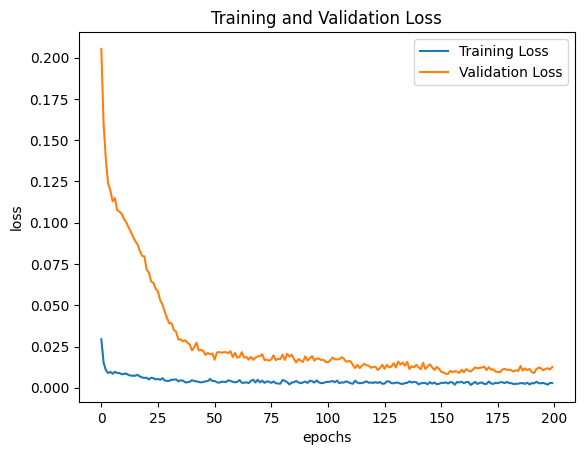

In [ ]:
# ambil statistik pelatihan
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(200)

# plot hasil loss pelatihan
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Training and Validation Loss')
plt.show()

# **7. Prediksi Data Test**

In [ ]:
from tensorflow.keras.models import load_model

# load hasil pelatihan untuk di uji
trained_model = load_model(checkpoint_filepath)

# Prediksi pada test dataset
testPredict = trained_model.predict(testX)

print(testY)
print(testPredict)

# Perhitungan RMSE (Root Mean Square Error) pada hasil prediksi
testScore = math.sqrt(mean_squared_error(testY, testPredict))
print('Test Score: %.2f RMSE' % (testScore))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
[[0.45945945]
 [0.5830116 ]
 [0.5637065 ]
 [0.61003864]
 [0.71042466]
 [0.8571429 ]
 [0.8783784 ]
 [0.69305015]
 [0.5849421 ]
 [0.4980695 ]
 [0.58108103]
 [0.6042471 ]
 [0.554054  ]
 [0.60810804]
 [0.6891892 ]
 [0.71042466]
 [0.8320464 ]
 [1.        ]
 [0.96911204]
 [0.7799227 ]
 [0.6891892 ]
 [0.55212355]
 [0.6332046 ]]
[[0.43136948]
 [0.40348077]
 [0.5020741 ]
 [0.48679543]
 [0.5233561 ]
 [0.6010426 ]
 [0.70957744]
 [0.7247045 ]
 [0.58777064]
 [0.5035985 ]
 [0.43446267]
 [0.5005489 ]
 [0.518807  ]
 [0.47913438]
 [0.5218404 ]
 [0.58481073]
 [0.6010426 ]
 [0.6914995 ]
 [0.8081806 ]
 [0.78750503]
 [0.6532868 ]
 [0.58481073]
 [0.47760057]]
Test Score: 0.14 RMSE


Hasil RMSE yang diperoleh adalah 0.14. Hal ini menunjukkan perbedaan antara hasil prediksi data ke t+1 dengan data t+1 sesungguhnya berkisar antara 0.14.  Menurut Anda apakah hasil ini sudah baik atau belum?

# **8. Visualisasi Hasil Prediksi pada Data Test dan Nilai Sebenarnya**

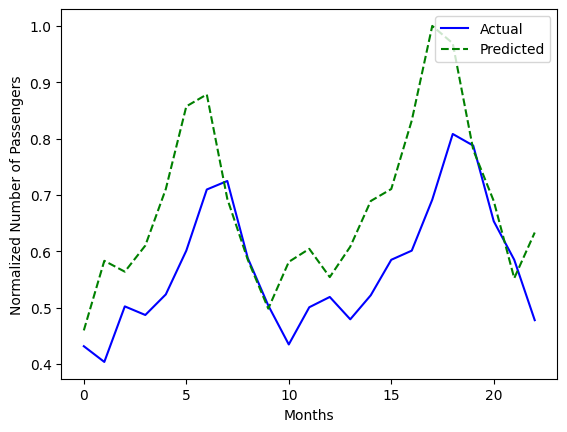

In [ ]:
# plot hasil prediksi dengan garis warna biru
plt.plot(testPredict, 'b-', label='Actual')
# plot hasil prediksi dengan garis putus-putus warna hijau
plt.plot(testY, 'g--', label='Predicted')
plt.xlabel('Months')
plt.ylabel('Normalized Number of Passengers')
plt.legend(loc='upper right')
plt.show()

## **Windowing**

Pada bagian selanjutnya kita akan mencoba menggunakan ukuran window lebih besar dari 1.  Kita akan mencoba menggunakan window berukuran 4. Artinya kita akan memprediksi data ke-t+1 dengan menggunakan 4 data sebelumnya yaitu data ke-t, data ke t-1, data ke t-2, dan data ke t-3. Dalam hal ini kita perlu mengubah sedikit fungsi create_dataset sebagai berikut.

In [ ]:
def create_dataset_window(dataset, look_back):
    dataX,dataY=[],[]

    for i in range(len(dataset)- look_back):
        a = []
        for j in range (0, look_back):
            a.append(dataset[i+j]) # a menyimpan data yang termasuk dalam window
        dataX.append(a)
        dataY.append(dataset[i + look_back])

    return numpy.array(dataX), numpy.array(dataY)

In [ ]:
# panggil fungsi create_dataset pada data yang sudah ternormalisasi
# dengan look_back = 4
# menghasilkan data X=t and Y=t+1
look_back = 4
trainX_window4, trainY_window4 = create_dataset_window(train, look_back)
testX_window4, testY_window4 = create_dataset_window(test, look_back)

In [ ]:
# tampilkan data yang telah dihasilkan
print(trainX_window4)
print(len(trainX_window4))

print(trainY_window4)
print(len(trainY_window4))

[[[0.01544401]
  [0.02702703]
  [0.05405405]
  [0.04826255]]

 [[0.02702703]
  [0.05405405]
  [0.04826255]
  [0.03281853]]

 [[0.05405405]
  [0.04826255]
  [0.03281853]
  [0.05984557]]

 [[0.04826255]
  [0.03281853]
  [0.05984557]
  [0.08494207]]

 [[0.03281853]
  [0.05984557]
  [0.08494207]
  [0.08494207]]

 [[0.05984557]
  [0.08494207]
  [0.08494207]
  [0.06177607]]

 [[0.08494207]
  [0.08494207]
  [0.06177607]
  [0.02895753]]

 [[0.08494207]
  [0.06177607]
  [0.02895753]
  [0.        ]]

 [[0.06177607]
  [0.02895753]
  [0.        ]
  [0.02702703]]

 [[0.02895753]
  [0.        ]
  [0.02702703]
  [0.02123553]]

 [[0.        ]
  [0.02702703]
  [0.02123553]
  [0.04247104]]

 [[0.02702703]
  [0.02123553]
  [0.04247104]
  [0.07142857]]

 [[0.02123553]
  [0.04247104]
  [0.07142857]
  [0.05984557]]

 [[0.04247104]
  [0.07142857]
  [0.05984557]
  [0.04054055]]

 [[0.07142857]
  [0.05984557]
  [0.04054055]
  [0.08687258]]

 [[0.05984557]
  [0.04054055]
  [0.08687258]
  [0.12741312]]

 [[0.040

Perhatikan pada trainX_window4 dari data yang kita hasilkan, data pertama terdiri dari data ke 1, 2, 3, 4.  Data kedua terdiri dari data ke 2,3,4,5. Data ketiga terdiri dari data ke 3,4,5,6. Sedangkan pada trainY_window4 data pertama adalah data ke 5, data kedua adalah data ke 6, data ketiga adalah data ke 7.

In [ ]:
# reshape input to be [samples, time steps, features]
trainX_window4 = numpy.reshape(trainX_window4,
                               (trainX_window4.shape[0], 1, trainX_window4.shape[1]))
testX_window4 = numpy.reshape(testX_window4,
                              (testX_window4.shape[0], 1, testX_window4.shape[1]))

In [ ]:
# membangun model dengan LSTM
model = Sequential()
#LSTM dengan 1 input dan 4 time-step dan LSTM memiliki 4 neuron/units
model.add(LSTM(4, input_shape=(1, 4)))
#Menambahkan Dropout untuk menghindari overfitting dengan dropout portion=0.5
model.add(Dropout(0.5))
# ouput prediksi memiliki 1 nilai saja
model.add(Dense(1))
model.compile(loss='mean_squared_error',
              optimizer='adam')

# menampilkan summary dari model yang dibuat
model.summary()

# simpan model yang mendapatkan akurasi validasi tertinggi
checkpoint_filepath = os.path.join(root_path, 'prak07_lstm_model_win4.h5')
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 4)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149 (596.00 B)

 Trainable params: 149 (596.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# epoch yang digunakan 200 dan batch_size = 1
model.fit(trainX_window4,
          trainY_window4,
          epochs=200,
          batch_size=1,
          callbacks=[model_checkpoint_callback],
          verbose=1,
          validation_split=0.4)

Epoch 1/200
59/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0198
Epoch 1: loss improved from inf to 0.01863, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model_win4.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0196 - val_loss: 0.1076
Epoch 2/200
62/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0124
Epoch 2: loss improved from 0.01863 to 0.00970, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model_win4.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0122 - val_loss: 0.0810
Epoch 3/200
61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0082
Epoch 3: loss improved from 0.00970 to 0.00684, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model_win4.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0080 - val_loss: 0.0684
Epoch 4/200
58/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073
Epoch 4: loss did not improve from 0.00684
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0073 - val_loss: 0.0659
Epoch 5/200
61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065
Epoch 5: loss improved from 0.00684 to 0.00665, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model_win4.h5


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - val_loss: 0.0548
Epoch 6/200
57/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074
Epoch 6: loss did not improve from 0.00665
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0073 - val_loss: 0.0561
Epoch 7/200
61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071
Epoch 7: loss improved from 0.00665 to 0.00631, saving model to gdrive/My Drive/Deep Learning Labs/labDL07 Data/prak07_lstm_model_win4.h5


...

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - val_loss: 0.0158
Epoch 59/200
65/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021
Epoch 59: loss did not improve from 0.00282
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0022 - val_loss: 0.0135
Epoch 60/200
58/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044
Epoch 60: loss did not improve from 0.00282
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0043 - val_loss: 0.0150
Epoch 61/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052
Epoch 61: loss did not improve from 0.00282
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050 - val_loss: 0.0156
Epoch 62/200
61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032
Epoch 62: loss did not improve from 0.00282
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0126
Epoch 63/200
57/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040
Epoch 63: loss did not improve from 0.00282
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 0.0129
Epoch 

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - val_loss: 0.0113
Epoch 69/200
59/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0053
Epoch 69: loss did not improve from 0.00257
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0050 - val_loss: 0.0125
Epoch 70/200
61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033
Epoch 70: loss did not improve from 0.00257
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0033 - val_loss: 0.0107
Epoch 71/200
58/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0024
Epoch 71: loss did not improve from 0.00257
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0025 - val_loss: 0.0113
Epoch 72/200
59/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028
Epoch 72: loss did not improve from 0.00257
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 0.0123
Epoch 73/200
58/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027
Epoch 73: loss did not improve from 0.00257
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 0.0123
Epoch 7

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022 - val_loss: 0.0118
Epoch 86/200
61/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031
Epoch 86: loss did not improve from 0.00215
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0108
Epoch 87/200
59/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033
Epoch 87: loss did not improve from 0.00215
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0034 - val_loss: 0.0092
Epoch 88/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029
Epoch 88: loss did not improve from 0.00215
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0029 - val_loss: 0.0096
Epoch 89/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028
Epoch 89: loss did not improve from 0.00215
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 0.0118
Epoch 90/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048
Epoch 90: loss did not improve from 0.00215
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0048 - val_loss: 0.0115
Epoch 

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0113
Epoch 143/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033
Epoch 143: loss did not improve from 0.00214
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0142
Epoch 144/200
59/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 144: loss did not improve from 0.00214
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035 - val_loss: 0.0152
Epoch 145/200
57/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 145: loss did not improve from 0.00214
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0121
Epoch 146/200
62/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033
Epoch 146: loss did not improve from 0.00214
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0111
Epoch 147/200
57/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031
Epoch 147: loss did not improve from 0.00214
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - val_loss: 0.0

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - val_loss: 0.0109
Epoch 156/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031
Epoch 156: loss did not improve from 0.00177
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_loss: 0.0120
Epoch 157/200
59/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026
Epoch 157: loss did not improve from 0.00177
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027 - val_loss: 0.0116
Epoch 158/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 158: loss did not improve from 0.00177
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0116
Epoch 159/200
56/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027
Epoch 159: loss did not improve from 0.00177
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - val_loss: 0.0100
Epoch 160/200
60/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 160: loss did not improve from 0.00177
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 0.01

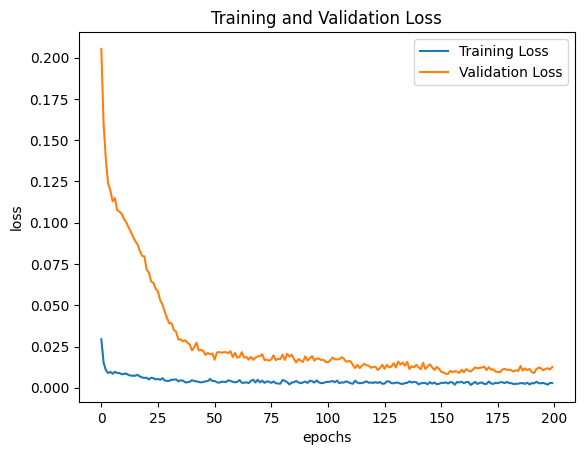

In [ ]:
# ambil statistik pelatihan
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(200)

# plot hasil loss pelatihan
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# load hasil pelatihan untuk di uji
trained_model = load_model(checkpoint_filepath)

# Prediksi pada test dataset
testPredict = trained_model.predict(testX_window4)

print(testY_window4)
print(testPredict)

# Perhitungan RMSE (Root Mean Square Error) pada hasil prediksi
testScore = math.sqrt(mean_squared_error(testY_window4, testPredict))
print('Test Score: %.2f RMSE' % (testScore))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
[[0.61003864]
 [0.71042466]
 [0.8571429 ]
 [0.8783784 ]
 [0.69305015]
 [0.5849421 ]
 [0.4980695 ]
 [0.58108103]
 [0.6042471 ]
 [0.554054  ]
 [0.60810804]
 [0.6891892 ]
 [0.71042466]
 [0.8320464 ]
 [1.        ]
 [0.96911204]
 [0.7799227 ]
 [0.6891892 ]
 [0.55212355]
 [0.6332046 ]]
[[0.47018442]
 [0.4771803 ]
 [0.5715487 ]
 [0.66426617]
 [0.66160285]
 [0.51882386]
 [0.46144265]
 [0.4384566 ]
 [0.48941287]
 [0.50647736]
 [0.4437249 ]
 [0.4896589 ]
 [0.56095666]
 [0.5584389 ]
 [0.636924  ]
 [0.7567459 ]
 [0.70674664]
 [0.5635669 ]
 [0.5329181 ]
 [0.47280794]]
Test Score: 0.18 RMSE


Perhatikan hasil RMSE 0.26, dengan menggunakan window berukuran 4 ternyata hasilnya TIDAK lebih baik dari pada menggunakan window berukuran 1 (RMSE 0.14). Semakin rendah nilai RMSE maka performa model semakin baik. Anda dapat bereksperimen dengan mengganti epoch yang lebih tinggi, menggunakan Dropout rate yang berbeda atau menggunakan ukuran window yang berbeda untuk mendapatkan hasil prediksi yang lebih baik (RMSE lebih rendah).

# **POST TEST**

Dengan menggunakan dataset yang sama (*airline_passangers.csv*) modifikasi lah fungsi create_dataset_window sehingga menghasilkan pola data sebagai berikut:

X : [data t-4, data t-2,  data t]

Y : [data t+2]

Artinya untuk memprediksi data t+2 kita gunakan data t-4, data t-2, dan data t.  Lalu lakukan prediksi dengan LSTM yang memiliki jumlah neuron 5. Gunakan epoch 100 dan batch size 1. Hitunglah hasil RMSE nya!

1. Modifikasi fungsi create_dataset_window

In [ ]:
import numpy as np

def create_dataset_window_modified(dataset, window_size=0):
    dataX, dataY = [], []
    for i in range(len(dataset)-window_size-2): # Mengurangi 2 untuk memastikan t+2 masih dalam rentang data
        # Periksa apakah indeks t-4, t-2, t, dan t+2 valid
        if (i - 4) >= 0 and (i - 2) >= 0 and (i + 2) < len(dataset):
            a = dataset[i-4:i-3, 0]  # data t-4
            b = dataset[i-2:i-1, 0]  # data t-2
            c = dataset[i:i+1, 0]    # data t
            dataX.append(np.concatenate((a, b, c)))
            dataY.append(dataset[i+2, 0]) # data t+2
    return np.array(dataX), np.array(dataY)

2. Melakukan Prediksi dengan LSTM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import math

In [ ]:
# Normalisasi data
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [ ]:
# Membagi data menjadi set pelatihan dan pengujian
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]


In [ ]:
# Buat dataset dengan jendela yang dimodifikasi
window_size = 0 # Tidak ada window size tambahan karena kita menggunakan indeks spesifik
trainX, trainY = create_dataset_window_modified(train, window_size)
testX, testY = create_dataset_window_modified(test, window_size)

In [ ]:
# Ubah bentuk input menjadi [sampel, langkah waktu, fitur]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [ ]:
# Buat dan sesuaikan jaringan LSTM
model = Sequential()
model.add(LSTM(5, input_shape=(1, trainX.shape[2]))) # 5 neuron
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=0)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Buat prediksi
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


In [ ]:
# Prediksi terbalik
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

In [ ]:
# RMSE
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train RMSE: %.2f' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test RMSE: %.2f' % (testScore))

Train RMSE: 0.07
Test RMSE: 0.17


In [ ]:
# Prediksi kereta shift untuk perencanaan
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# Sesuaikan start_index untuk trainPredictPlot karena data latih dimulai dari indeks 4
trainPredictPlot[4:len(trainPredict)+4, :] = trainPredict



In [ ]:
# Shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
test_start_index = len(trainPredict) + 4 + 2 # tambahkan 2 karena kita memprediksi t+2



In [ ]:
# Pastikan indeks tidak melebihi batas dataset
if test_start_index + len(testPredict) <= len(dataset):
    testPredictPlot[test_start_index:test_start_index + len(testPredict), :] = testPredict
else:
    # Jika prediksi test melebihi batas, potong prediksi testPlot
    testPredictPlot[test_start_index:len(dataset), :] = testPredict[:len(dataset)-test_start_index, :]




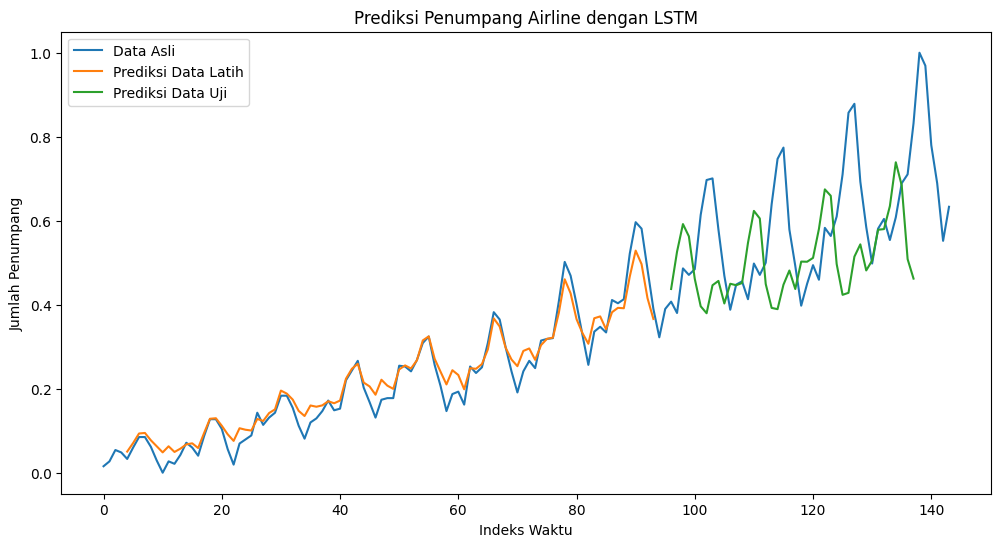

In [ ]:
# Plot garis dasar dan prediksi
plt.figure(figsize=(12, 6))
plt.plot(dataset, label='Data Asli')
plt.plot(trainPredictPlot, label='Prediksi Data Latih')
plt.plot(testPredictPlot, label='Prediksi Data Uji')
plt.title('Prediksi Penumpang Airline dengan LSTM')
plt.xlabel('Indeks Waktu')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.show()

Kesimpulan

Dalam postest ini, saya memodifikasi fungsi create_dataset_window untuk membuat dataset time-series dengan pola input X: [data t-4, data t-2, data t] dan output Y: [data t+2]. Kemudian, kita melatih model Long Short Term Memory (LSTM) dengan 5 neuron menggunakan dataset tersebut untuk memprediksi jumlah penumpang maskapai. Hasil performa model diukur menggunakan Root Mean Squared Error (RMSE) untuk data latih dan data uji. Terakhir, kita memvisualisasikan hasil prediksi model terhadap data asli untuk melihat kecocokan dan akurasi model secara visual.